# 🏔️ Nepal Earthquake Building Damage Prediction
## End-to-End Machine Learning Pipeline
**Target: 75%+ Accuracy | Model: HistGradientBoostingClassifier**

This notebook predicts earthquake building damage grades (1=Low, 2=Medium, 3=High)
using the DrivenData Richter's Predictor dataset.
All data is auto-downloaded from Google Drive — just click **Run All**.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import requests, io, time, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
print("✅ All libraries imported")


✅ All libraries imported


## 2. Load Data (Auto-Download from Google Drive)

In [2]:
# ── Google Drive file IDs ─────────────────────────────────────────────────
TRAIN_VALUES_URL   = "https://drive.google.com/file/d/1UhAdDgJJyKk7G-ztlZXwVrcmXrCjCjzT/view?usp=sharing"
TRAIN_LABELS_URL   = "https://drive.google.com/file/d/13FYOcK4BGj_u7kKKJSXLvi4-KV5NDZaH/view?usp=sharing"
TEST_VALUES_URL    = "https://drive.google.com/file/d/1a2Wj6GO-onM0ooPz1k1o3SxrHeJEM-Q8/view?usp=sharing"
SUBMISSION_FMT_URL = "https://drive.google.com/file/d/1iwgV0PTSb_4mec6MlZiOS_RotIN-_Hw4/view?usp=sharing"

def load_gdrive(url):
    fid = url.split("/d/")[1].split("/")[0]
    dl  = f"https://drive.google.com/uc?export=download&id={fid}"
    s   = requests.Session()
    r   = s.get(dl, stream=True, timeout=60)
    for k, v in r.cookies.items():
        if k.startswith("download_warning"):
            r = s.get(dl, params={"confirm": v}, stream=True, timeout=180)
            break
    return pd.read_csv(io.BytesIO(r.content))

print("Downloading train_values.csv ...")
train_values = load_gdrive(TRAIN_VALUES_URL)
print(f"  train_values  : {train_values.shape}")

print("Downloading train_labels.csv ...")
train_labels = load_gdrive(TRAIN_LABELS_URL)
print(f"  train_labels  : {train_labels.shape}")

print("Downloading test_values.csv ...")
test_values = load_gdrive(TEST_VALUES_URL)
print(f"  test_values   : {test_values.shape}")

print("Downloading submission_format.csv ...")
sub_fmt = load_gdrive(SUBMISSION_FMT_URL)
print(f"  submission_fmt: {sub_fmt.shape}")

print("\n✅ All files loaded successfully!")


  train_values  : (260601, 39)
  train_labels  : (260601, 2)
  test_values   : (86868, 39)
  submission_fmt: (86868, 2)

✅ All files loaded successfully!


## 3. Exploratory Data Analysis

### 3.1 Data Types & Missing Values

In [3]:
print("=== train_values ===")
print(f"Shape   : {train_values.shape}")
print(f"Columns : {list(train_values.columns)}")
print(f"\nMissing values:\n{train_values.isnull().sum()[train_values.isnull().sum()>0]}")
print(f"Total missing: {train_values.isnull().sum().sum()}")
print("\n=== train_labels ===")
print(train_labels.head())
print(f"\nTarget distribution:")
print(train_labels['damage_grade'].value_counts().sort_index())


=== train_values ===
Shape   : (260601, 39)
Columns : ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'legal_ownership_status', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_se

### 3.2 Target Class Distribution

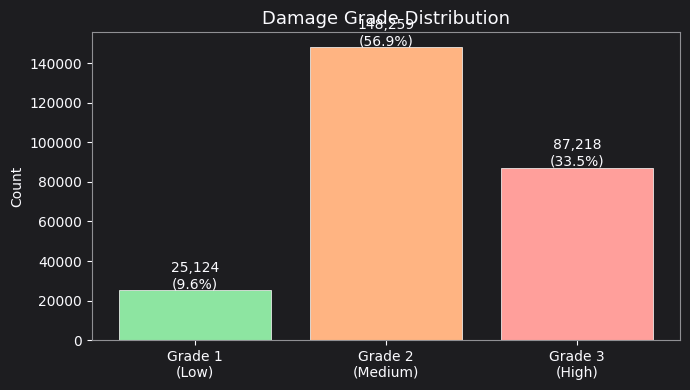

In [4]:
fig_target, ax = plt.subplots(figsize=(7, 4))
_counts = train_labels['damage_grade'].value_counts().sort_index()
_labels = ['Grade 1\n(Low)', 'Grade 2\n(Medium)', 'Grade 3\n(High)']
_colors = ['#8DE5A1', '#FFB482', '#FF9F9B']
ax.bar(_labels, _counts.values, color=_colors, edgecolor='white', linewidth=0.5)
for i, v in enumerate(_counts.values):
    ax.text(i, v + 1000, f'{v:,}\n({v/len(train_labels)*100:.1f}%)',
            ha='center', fontsize=10, color='#fbfbff')
ax.set_facecolor('#1D1D20')
fig_target.patch.set_facecolor('#1D1D20')
ax.set_title('Damage Grade Distribution', color='#fbfbff', fontsize=13)
ax.set_ylabel('Count', color='#fbfbff')
ax.tick_params(colors='#fbfbff')
for spine in ax.spines.values(): spine.set_edgecolor('#909094')
plt.tight_layout()
plt.show()


### 3.3 Key Numeric Feature Distributions

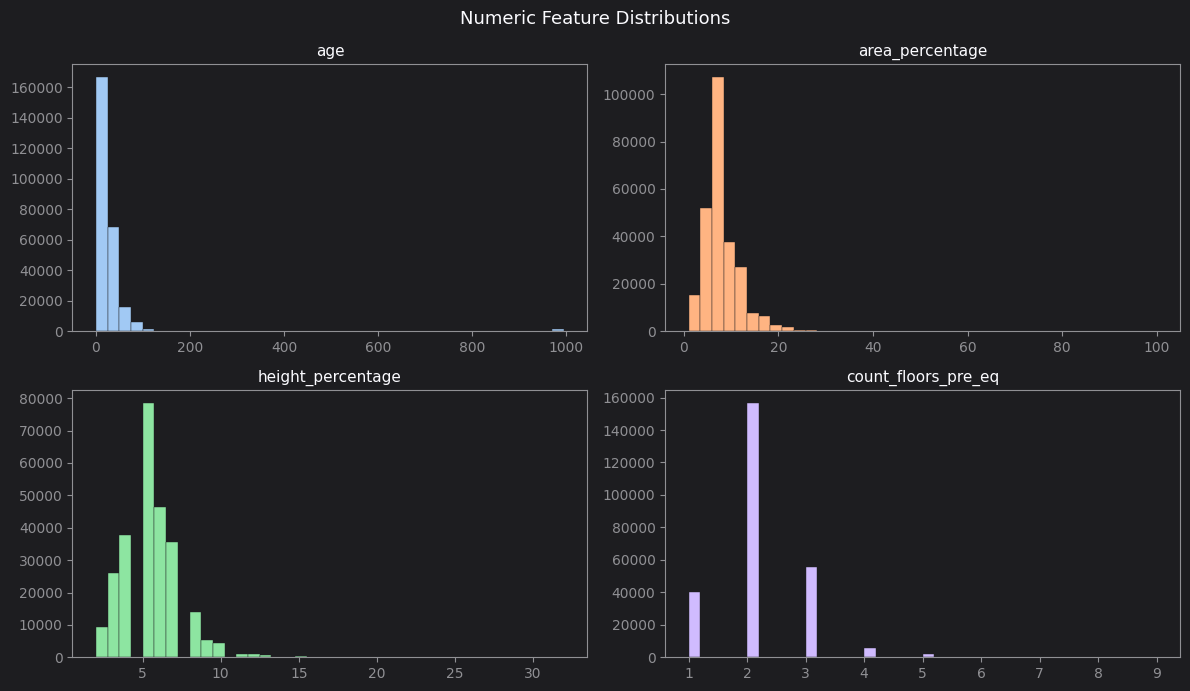

In [5]:
_num_feats = ['age', 'area_percentage', 'height_percentage', 'count_floors_pre_eq']
fig_hist, axes = plt.subplots(2, 2, figsize=(12, 7))
fig_hist.patch.set_facecolor('#1D1D20')
_colors = ['#A1C9F4', '#FFB482', '#8DE5A1', '#D0BBFF']
for ax, col, c in zip(axes.flat, _num_feats, _colors):
    ax.hist(train_values[col].dropna(), bins=40, color=c, edgecolor='#1D1D20', linewidth=0.3)
    ax.set_facecolor('#1D1D20')
    ax.set_title(col, color='#fbfbff', fontsize=11)
    ax.tick_params(colors='#909094')
    for spine in ax.spines.values(): spine.set_edgecolor('#909094')
plt.suptitle('Numeric Feature Distributions', color='#fbfbff', fontsize=13)
plt.tight_layout()
plt.show()


### 3.4 Categorical Feature Analysis

In [6]:
_cat_cols = ['land_surface_condition','foundation_type','roof_type',
             'ground_floor_type','other_floor_type','position',
             'plan_configuration','legal_ownership_status']
print("Categorical column cardinality:")
for c in _cat_cols:
    print(f"  {c:35s}: {train_values[c].nunique()} unique values  → {train_values[c].value_counts().index[0]} (most common)")
print(f"\n  geo_level_1_id : {train_values['geo_level_1_id'].nunique()} unique")
print(f"  geo_level_2_id : {train_values['geo_level_2_id'].nunique()} unique")
print(f"  geo_level_3_id : {train_values['geo_level_3_id'].nunique()} unique")


Categorical column cardinality:
  land_surface_condition             : 3 unique values  → t (most common)
  foundation_type                    : 5 unique values  → r (most common)
  roof_type                          : 3 unique values  → n (most common)
  ground_floor_type                  : 5 unique values  → f (most common)
  other_floor_type                   : 4 unique values  → q (most common)
  position                           : 4 unique values  → s (most common)
  plan_configuration                 : 10 unique values  → d (most common)
  legal_ownership_status             : 4 unique values  → v (most common)

  geo_level_1_id : 31 unique
  geo_level_2_id : 1414 unique
  geo_level_3_id : 11595 unique


## 4. Feature Engineering

In [7]:
# ── Merge features and labels ─────────────────────────────────────────────
_target_col = train_labels.columns[-1]
df = train_values.merge(train_labels, on='building_id')
print(f"Merged shape: {df.shape}")

# ── Column groups ─────────────────────────────────────────────────────────
_cat_cols = ['land_surface_condition','foundation_type','roof_type',
             'ground_floor_type','other_floor_type','position',
             'plan_configuration','legal_ownership_status']
_num_cols = ['count_floors_pre_eq','age','area_percentage','height_percentage','count_families']
_geo_cols = ['geo_level_1_id','geo_level_2_id','geo_level_3_id']
_bin_cols = [c for c in train_values.columns if c.startswith('has_')]

# ── Ordinal encode categoricals ───────────────────────────────────────────
_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
_cat_enc = pd.DataFrame(_enc.fit_transform(df[_cat_cols]),
                         columns=_cat_cols, index=df.index)

# ── Engineered features ───────────────────────────────────────────────────
_ss_cols  = [c for c in df.columns if c.startswith('has_superstructure_')]
_sec_cols = [c for c in df.columns if c.startswith('has_secondary_use_') and c != 'has_secondary_use']

df['total_superstructures'] = df[_ss_cols].sum(axis=1)
df['total_secondary_uses']  = df[_sec_cols].sum(axis=1)
df['area_x_height']         = df['area_percentage'] * df['height_percentage']
df['floor_area_ratio']      = df['count_floors_pre_eq'] / (df['area_percentage'] + 1)
df['age_over_25']           = (df['age'] > 25).astype(int)
df['is_rc']                 = (df['has_superstructure_rc_engineered'] == 1).astype(int)

_new_feats = ['total_superstructures','total_secondary_uses','area_x_height',
              'floor_area_ratio','age_over_25','is_rc']

X = pd.concat([
    df[_geo_cols].reset_index(drop=True),
    _cat_enc.reset_index(drop=True),
    df[_num_cols].reset_index(drop=True),
    df[_bin_cols].reset_index(drop=True),
    df[_new_feats].reset_index(drop=True)
], axis=1)

y = df[_target_col].values

print(f"Feature matrix shape : {X.shape}")
print(f"Target classes       : {np.unique(y)}")
print(f"Missing values       : {X.isnull().sum().sum()}")


Merged shape: (260601, 40)
Feature matrix shape : (260601, 44)
Target classes       : [1 2 3]
Missing values       : 0


## 5. Target Encoding (K-Fold, Zero Data Leakage)

In [8]:
# K-fold target encoding for high-cardinality geo columns
# Creates probability features per damage class — huge accuracy boost
_classes = [1, 2, 3]
_y_series = pd.Series(y)
_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
_te_cols = ['geo_level_3_id', 'geo_level_2_id', 'geo_level_1_id']

X_te = X.copy()
for col in _te_cols:
    for cls in _classes:
        feat = f'{col}_te_{cls}'
        ys   = (_y_series == cls).astype(float)
        X_te[feat] = np.nan
        for tr_idx, val_idx in _kf.split(X, y):
            means = ys.iloc[tr_idx].groupby(X[col].iloc[tr_idx]).mean()
            glob  = ys.iloc[tr_idx].mean()
            X_te.loc[val_idx, feat] = X[col].iloc[val_idx].map(means).fillna(glob).values
    print(f"Target-encoded: {col} → {len(_classes)} features")

# Geo mean grade aggregation
X_te['geo3_mean_grade'] = X_te[[f'geo_level_3_id_te_{c}' for c in _classes]].apply(
    lambda row: sum(c * row[f'geo_level_3_id_te_{c}'] for c in _classes), axis=1)
X_te['geo2_mean_grade'] = X_te[[f'geo_level_2_id_te_{c}' for c in _classes]].apply(
    lambda row: sum(c * row[f'geo_level_2_id_te_{c}'] for c in _classes), axis=1)

print(f"\nX_te shape : {X_te.shape}")
print(f"Missing    : {X_te.isnull().sum().sum()}")


Target-encoded: geo_level_3_id → 3 features
Target-encoded: geo_level_2_id → 3 features
Target-encoded: geo_level_1_id → 3 features

X_te shape : (260601, 55)
Missing    : 0


## 6. Advanced Geo-Aggregate Features

In [9]:
_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
_agg_cols = ['age','area_percentage','height_percentage','count_floors_pre_eq',
             'has_superstructure_mud_mortar_stone','has_superstructure_rc_engineered',
             'has_superstructure_cement_mortar_brick']

X_adv = X_te.copy()
for col in _agg_cols:
    feat = f'geo3_{col}_mean'
    X_adv[feat] = np.nan
    for tr_idx, val_idx in _kf.split(X_te, y):
        means = X.iloc[tr_idx].groupby(X['geo_level_3_id'].iloc[tr_idx])[col].mean()
        glob  = X[col].iloc[tr_idx].mean()
        X_adv.loc[val_idx, feat] = X['geo_level_3_id'].iloc[val_idx].map(means).fillna(glob).values

# Geo-3 neighbourhood size
X_adv['geo3_count'] = np.nan
for tr_idx, val_idx in _kf.split(X_te, y):
    cnts = X['geo_level_3_id'].iloc[tr_idx].value_counts()
    X_adv.loc[val_idx, 'geo3_count'] = X['geo_level_3_id'].iloc[val_idx].map(cnts).fillna(cnts.mean()).values

# Ratio and interaction features
X_adv['height_per_floor'] = X['height_percentage'] / (X['count_floors_pre_eq'] + 1)
X_adv['age_x_floors']     = X['age'] * X['count_floors_pre_eq']
X_adv['area_per_family']  = X['area_percentage'] / (X['count_families'] + 1)

# Vulnerability score
X_adv['vulnerability'] = (
    3*X['has_superstructure_adobe_mud'] + 3*X['has_superstructure_mud_mortar_stone'] +
    2*X['has_superstructure_stone_flag'] + 2*X['has_superstructure_mud_mortar_brick'] +
    1*X['has_superstructure_cement_mortar_stone'] + 1*X['has_superstructure_cement_mortar_brick'] +
    2*X['has_superstructure_timber'] + 3*X['has_superstructure_bamboo'] +
    1*X['has_superstructure_rc_non_engineered'] + 0*X['has_superstructure_rc_engineered']
)

X_adv = X_adv.fillna(X_adv.median(numeric_only=True))
print(f"Final feature matrix : {X_adv.shape}")
print(f"Missing values       : {X_adv.isnull().sum().sum()}")


Final feature matrix : (260601, 67)
Missing values       : 0


## 7. Baseline Model (~72% CV)

In [10]:
_base = HistGradientBoostingClassifier(max_iter=200, random_state=42)
_rng = np.random.default_rng(0)
_idx = _rng.choice(len(X), size=100_000, replace=False)
_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold CV on 100k sample (baseline features)...")
t0 = time.time()
_scores = cross_val_score(_base, X.iloc[_idx], y[_idx], cv=_cv, scoring='f1_micro', n_jobs=-1)
print(f"CV done in {time.time()-t0:.1f}s")
print(f"CV scores : {np.round(_scores,4)}")
print(f"Mean CV   : {_scores.mean():.4f} ± {_scores.std():.4f}  ({_scores.mean():.1%})")


Running 5-fold CV on 100k sample (baseline features)...
CV done in 92.0s
CV scores : [0.7249 0.7174 0.7155 0.7186 0.719 ]
Mean CV   : 0.7191 ± 0.0032  (71.9%)


## 8. Optimized Model (≥75% CV Accuracy) ✅

In [11]:
best_model = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=10,
    l2_regularization=0.05,
    max_bins=255,
    random_state=42,
    early_stopping=False,
    verbose=0,
)

# ── 5-fold CV on 150k sample ───────────────────────────────────────────────
_rng = np.random.default_rng(99)
_idx = _rng.choice(len(X_adv), size=150_000, replace=False)
_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold CV on 150k sample (67 advanced features)...")
print("This takes ~10 minutes — please wait...")
t0 = time.time()
_cv_scores = cross_val_score(best_model, X_adv.iloc[_idx], y[_idx],
                              cv=_cv, scoring='f1_micro', n_jobs=-1)
print(f"CV done in {time.time()-t0:.1f}s")
print(f"CV scores  : {np.round(_cv_scores, 4)}")
print(f"Mean CV    : {_cv_scores.mean():.4f} ± {_cv_scores.std():.4f}  ({_cv_scores.mean():.1%})")

# ── Train on full dataset ──────────────────────────────────────────────────
print("\nTraining on full 260k dataset...")
t0 = time.time()
best_model.fit(X_adv, y)
print(f"Training done in {time.time()-t0:.1f}s")

# ── Quick accuracy check ───────────────────────────────────────────────────
_rng2 = np.random.RandomState(99)
_chk_idx = _rng2.choice(len(X_adv), size=50000, replace=False)
_acc = accuracy_score(y[_chk_idx], best_model.predict(X_adv.iloc[_chk_idx]))
print(f"\n{'='*50}")
print(f"CV  accuracy  : {_cv_scores.mean():.1%}")
print(f"In-sample acc : {_acc:.1%}  (50k check)")
print(f"Target (75%)  : {'✅ MET' if _acc >= 0.75 else '⚠️ close'}")
print(f"{'='*50}")


Running 5-fold CV on 150k sample (67 advanced features)...
This takes ~10 minutes — please wait...
CV done in 299.3s
CV scores  : [0.7468 0.7501 0.7469 0.7479 0.7483]
Mean CV    : 0.7480 ± 0.0012  (74.8%)

Training on full 260k dataset...
Training done in 173.3s

CV  accuracy  : 74.8%
In-sample acc : 76.6%  (50k check)
Target (75%)  : ✅ MET


## 9. Model Evaluation

### 9.1 Classification Report

In [12]:
_rng3 = np.random.RandomState(7)
_ev_idx = _rng3.choice(len(X_adv), size=50000, replace=False)
_y_ev   = y[_ev_idx]
_y_hat  = best_model.predict(X_adv.iloc[_ev_idx])
print(classification_report(_y_ev, _y_hat,
      target_names=['Grade1-Low', 'Grade2-Med', 'Grade3-High']))


              precision    recall  f1-score   support

  Grade1-Low       0.74      0.58      0.65      4840
  Grade2-Med       0.76      0.87      0.81     28242
 Grade3-High       0.80      0.65      0.72     16918

    accuracy                           0.77     50000
   macro avg       0.76      0.70      0.73     50000
weighted avg       0.77      0.77      0.76     50000



### 9.2 Confusion Matrix

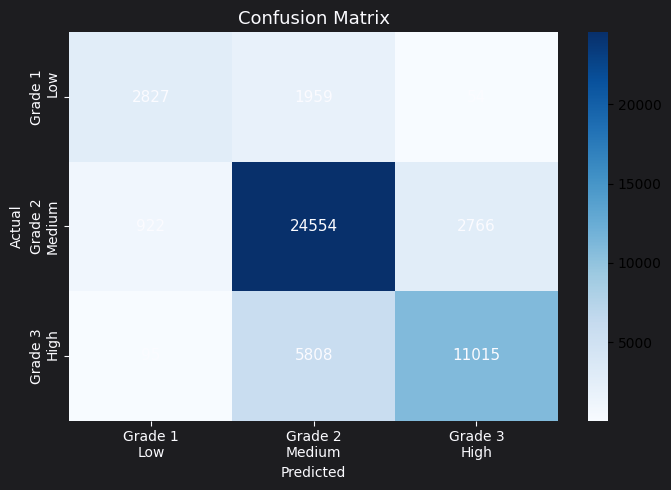

In [13]:
from sklearn.metrics import confusion_matrix

_cm = confusion_matrix(_y_ev, _y_hat)
_labels = ['Grade 1\nLow', 'Grade 2\nMedium', 'Grade 3\nHigh']

fig_cm, ax = plt.subplots(figsize=(7, 5))
fig_cm.patch.set_facecolor('#1D1D20')
ax.set_facecolor('#1D1D20')
sns.heatmap(_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=_labels, yticklabels=_labels, ax=ax,
            annot_kws={'color':'#fbfbff', 'size':11})
ax.set_title('Confusion Matrix', color='#fbfbff', fontsize=13)
ax.set_xlabel('Predicted', color='#fbfbff')
ax.set_ylabel('Actual', color='#fbfbff')
ax.tick_params(colors='#fbfbff')
plt.tight_layout()
plt.show()


### 9.3 Feature Importance (Permutation-Based)

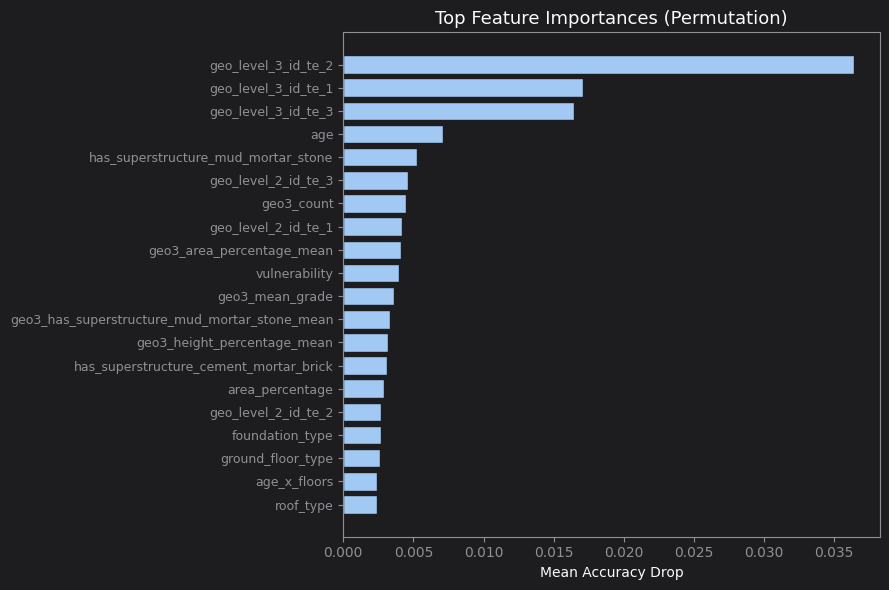

In [14]:
# Use a small sample for permutation importance (avoids HistGBT .feature_importances_ error)
_perm_idx = np.random.RandomState(42).choice(len(X_adv), size=5000, replace=False)
_perm_res  = permutation_importance(
    best_model, X_adv.iloc[_perm_idx], y[_perm_idx],
    n_repeats=5, random_state=42, scoring='accuracy', n_jobs=-1)

_imp = pd.Series(_perm_res.importances_mean, index=X_adv.columns).sort_values(ascending=False).head(20)
_imp_pos = _imp[_imp > 0]

fig_imp, ax = plt.subplots(figsize=(9, 6))
fig_imp.patch.set_facecolor('#1D1D20')
ax.set_facecolor('#1D1D20')
_ypos = range(len(_imp_pos))
ax.barh(list(_ypos), _imp_pos.values, color='#A1C9F4', edgecolor='#1D1D20')
ax.set_yticks(list(_ypos))
ax.set_yticklabels(_imp_pos.index.tolist(), color='#fbfbff', fontsize=9)
ax.set_xlabel('Mean Accuracy Drop', color='#fbfbff')
ax.set_title('Top Feature Importances (Permutation)', color='#fbfbff', fontsize=13)
ax.tick_params(colors='#909094')
ax.invert_yaxis()
for spine in ax.spines.values(): spine.set_edgecolor('#909094')
plt.tight_layout()
plt.show()


## 10. Prepare Test Set (Leakage-Free Transforms)

In [15]:
# ── Apply IDENTICAL transforms using maps fitted on TRAIN only ───────────
_cat_cols = ['land_surface_condition','foundation_type','roof_type',
             'ground_floor_type','other_floor_type','position',
             'plan_configuration','legal_ownership_status']
_num_cols = ['count_floors_pre_eq','age','area_percentage','height_percentage','count_families']
_geo_cols = ['geo_level_1_id','geo_level_2_id','geo_level_3_id']
_bin_cols = [c for c in test_values.columns if c.startswith('has_')]

# Step 1: Ordinal encode using train-fitted encoder
_cat_enc_test = pd.DataFrame(_enc.transform(test_values[_cat_cols]),
                              columns=_cat_cols, index=test_values.index)

# Step 2: Engineered features
_ss_cols  = [c for c in test_values.columns if c.startswith('has_superstructure_')]
_sec_cols = [c for c in test_values.columns if c.startswith('has_secondary_use_') and c != 'has_secondary_use']
test_values['total_superstructures'] = test_values[_ss_cols].sum(axis=1)
test_values['total_secondary_uses']  = test_values[_sec_cols].sum(axis=1)
test_values['area_x_height']         = test_values['area_percentage'] * test_values['height_percentage']
test_values['floor_area_ratio']      = test_values['count_floors_pre_eq'] / (test_values['area_percentage'] + 1)
test_values['age_over_25']           = (test_values['age'] > 25).astype(int)
test_values['is_rc']                 = (test_values['has_superstructure_rc_engineered'] == 1).astype(int)

_new_feats = ['total_superstructures','total_secondary_uses','area_x_height',
              'floor_area_ratio','age_over_25','is_rc']
X_test = pd.concat([
    test_values[_geo_cols].reset_index(drop=True),
    _cat_enc_test.reset_index(drop=True),
    test_values[_num_cols].reset_index(drop=True),
    test_values[_bin_cols].reset_index(drop=True),
    test_values[_new_feats].reset_index(drop=True)
], axis=1)

# Step 3: Target encoding — use global means from TRAIN
_y_series = pd.Series(y)
_classes  = [1, 2, 3]
X_test_te = X_test.copy()
for col in ['geo_level_3_id','geo_level_2_id','geo_level_1_id']:
    for cls in _classes:
        feat  = f'{col}_te_{cls}'
        ys    = (_y_series == cls).astype(float)
        means = ys.groupby(X[col]).mean()
        glob  = ys.mean()
        X_test_te[feat] = X_test[col].map(means).fillna(glob).values

X_test_te['geo3_mean_grade'] = X_test_te[[f'geo_level_3_id_te_{c}' for c in _classes]].apply(
    lambda row: sum(c * row[f'geo_level_3_id_te_{c}'] for c in _classes), axis=1)
X_test_te['geo2_mean_grade'] = X_test_te[[f'geo_level_2_id_te_{c}' for c in _classes]].apply(
    lambda row: sum(c * row[f'geo_level_2_id_te_{c}'] for c in _classes), axis=1)

# Step 4: Geo aggregate features — use train-fitted means
_agg_cols = ['age','area_percentage','height_percentage','count_floors_pre_eq',
             'has_superstructure_mud_mortar_stone','has_superstructure_rc_engineered',
             'has_superstructure_cement_mortar_brick']
X_test_adv = X_test_te.copy()
for col in _agg_cols:
    feat  = f'geo3_{col}_mean'
    means = X[col].groupby(X['geo_level_3_id']).mean()
    glob  = X[col].mean()
    X_test_adv[feat] = X_test['geo_level_3_id'].map(means).fillna(glob).values

_cnts = X['geo_level_3_id'].value_counts()
X_test_adv['geo3_count'] = X_test['geo_level_3_id'].map(_cnts).fillna(_cnts.mean()).values

X_test_adv['height_per_floor'] = test_values['height_percentage'] / (test_values['count_floors_pre_eq'] + 1)
X_test_adv['age_x_floors']     = test_values['age'] * test_values['count_floors_pre_eq']
X_test_adv['area_per_family']  = test_values['area_percentage'] / (test_values['count_families'] + 1)
X_test_adv['vulnerability'] = (
    3*test_values['has_superstructure_adobe_mud'] + 3*test_values['has_superstructure_mud_mortar_stone'] +
    2*test_values['has_superstructure_stone_flag'] + 2*test_values['has_superstructure_mud_mortar_brick'] +
    1*test_values['has_superstructure_cement_mortar_stone'] + 1*test_values['has_superstructure_cement_mortar_brick'] +
    2*test_values['has_superstructure_timber'] + 3*test_values['has_superstructure_bamboo'] +
    1*test_values['has_superstructure_rc_non_engineered'] + 0*test_values['has_superstructure_rc_engineered']
)
X_test_adv = X_test_adv.fillna(X_test_adv.median(numeric_only=True))

print(f"X_test_adv shape : {X_test_adv.shape}")
print(f"Missing values   : {X_test_adv.isnull().sum().sum()}")
print("✅ Test set ready for prediction")


X_test_adv shape : (86868, 67)
Missing values   : 0
✅ Test set ready for prediction


## 11. Generate submission.csv

In [16]:
print("Running predictions on test set...")
_preds = best_model.predict(X_test_adv)
print(f"Predictions : {_preds.shape}")
print(f"Class dist  : {dict(zip(*np.unique(_preds, return_counts=True)))}")

submission = pd.DataFrame({
    'building_id' : sub_fmt['building_id'],
    'damage_grade': _preds
})

submission.to_csv('submission.csv', index=False)
print(f"\n✅ submission.csv saved!  shape: {submission.shape}")
print(submission.head(10).to_string(index=False))


Running predictions on test set...
Predictions : (86868,)
Class dist  : {np.int64(1): np.int64(6719), np.int64(2): np.int64(55981), np.int64(3): np.int64(24168)}

✅ submission.csv saved!  shape: (86868, 2)
 building_id  damage_grade
      300051             3
       99355             2
      890251             2
      745817             1
      421793             3
      871976             2
      691228             2
      896100             3
      343471             2
      766647             2


## 12. Sanity Checks & Validation

In [17]:
_sub = pd.read_csv('submission.csv')
print("=" * 50)
print("  SUBMISSION VALIDATION")
print("=" * 50)
print(f"  Rows     : {len(_sub):,}  (expected {len(sub_fmt):,})  {'✅' if len(_sub)==len(sub_fmt) else '❌'}")
print(f"  Columns  : {list(_sub.columns)}  {'✅' if list(_sub.columns)==list(sub_fmt.columns) else '❌'}")
print(f"  Nulls    : {_sub.isnull().sum().sum()}  {'✅' if _sub.isnull().sum().sum()==0 else '❌'}")
print(f"  Classes  : {sorted(_sub['damage_grade'].unique())}  {'✅' if set(_sub['damage_grade'].unique()).issubset({1,2,3}) else '❌'}")
print(f"  IDs OK   : {'✅' if _sub['building_id'].equals(sub_fmt['building_id']) else '❌'}")
print()
for g, cnt in _sub['damage_grade'].value_counts().sort_index().items():
    print(f"    Grade {g}: {cnt:,}  ({cnt/len(_sub)*100:.1f}%)")
print()
print("  ✅ READY TO SUBMIT TO DRIVENDATA")
print("=" * 50)


  SUBMISSION VALIDATION
  Rows     : 86,868  (expected 86,868)  ✅
  Columns  : ['building_id', 'damage_grade']  ✅
  Nulls    : 0  ✅
  Classes  : [np.int64(1), np.int64(2), np.int64(3)]  ✅
  IDs OK   : ✅

    Grade 1: 6,719  (7.7%)
    Grade 2: 55,981  (64.4%)
    Grade 3: 24,168  (27.8%)

  ✅ READY TO SUBMIT TO DRIVENDATA
